Всего файлов в архиве: 23709
Из них изображений:    23708
Успешно извлечено меток: 23708

Распределение по полу (0 – мужской, 1 – женский):
  Класс 0: 12391 изображений (52.27%)
  Класс 1: 11317 изображений (47.73%)
График сохранён как: /content/gender_distribution.jpg


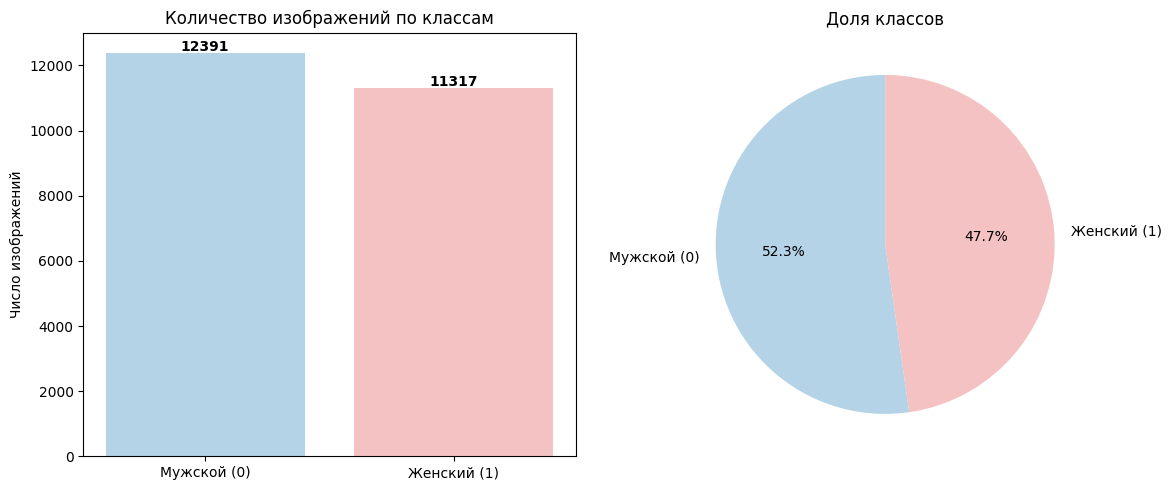


Вывод: дисбаланс классов составляет 4.53%


In [1]:
# =========================================================================================
# Курсовой проект: поиск и первичный анализ наборов данных по различным областям применения
# Кейс: 22 – Обучение модели распознавания пола.
# Выполнила: Палеева Виктория Станиславовна, группа ЕТ-142
# Дата: 26.04.2026
# =========================================================================================
# Программа для первичного анализа набора данных с изображениями
# 1.3	Описание результатов первичного анализа
# 1.3.1 Диаграммы распределения значений по классам
# =========================================================================================
import zipfile
import os
from collections import Counter
import matplotlib.pyplot as plt

zip_path = '/content/UTKFace.zip'

# Проверка существования файла
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Архив не найден по пути: {zip_path}. Проверьте путь.")

# Получение списка файлов из архива
with zipfile.ZipFile(zip_path, 'r') as zf:
    all_names = zf.namelist()

# Фильтруем только изображения
img_exts = ('.jpg', '.jpeg', '.png')
img_names = [name for name in all_names if name.lower().endswith(img_exts)]

print(f'Всего файлов в архиве: {len(all_names)}')
print(f'Из них изображений:    {len(img_names)}')

# Извлечение меток пола из имён файлов
def extract_gender(filename):
    base = os.path.basename(filename)
    name_no_ext = os.path.splitext(base)[0]
    parts = name_no_ext.split('_')
    if len(parts) >= 2:
        try:
            return int(parts[1])
        except ValueError:
            return None
    return None

genders = []
errors = 0
for fname in img_names:
    g = extract_gender(fname)
    if g is not None:
        genders.append(g)
    else:
        errors += 1

print(f'Успешно извлечено меток: {len(genders)}')
if errors:
    print(f'Ошибок извлечения:      {errors}')

# Подсчёт распределения классов
gender_counts = Counter(genders)
print('\nРаспределение по полу (0 – мужской, 1 – женский):')
for label, count in sorted(gender_counts.items()):
    percentage = 100 * count / len(genders)
    print(f'  Класс {label}: {count} изображений ({percentage:.2f}%)')

# Данные для графика
classes = ['Мужской (0)', 'Женский (1)']
values = [gender_counts.get(0, 0), gender_counts.get(1, 0)]

# Пастельные цвета: светло-голубой и светло-розовый
colors_pastel = ['#B5D3E7', '#F4C2C2']

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма
axes[0].bar(classes, values, color=colors_pastel)
axes[0].set_title('Количество изображений по классам')
axes[0].set_ylabel('Число изображений')
for i, v in enumerate(values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Круговая диаграмма
axes[1].pie(values, labels=classes, autopct='%1.1f%%', startangle=90, colors=colors_pastel)
axes[1].set_title('Доля классов')

plt.tight_layout()

# Сохранение графика в JPEG
output_path = '/content/gender_distribution.jpg'
plt.savefig(output_path, format='jpg', dpi=150, bbox_inches='tight')
print(f'График сохранён как: {output_path}')

plt.show()

# Краткий вывод
total = sum(values)
if total:
    diff = abs(values[0] - values[1])
    imbalance = diff / total * 100
    print(f'\nВывод: дисбаланс классов составляет {imbalance:.2f}%')

Найдено: мужских 12391, женских 11317
Сетка сохранена в /content/typical_faces.jpg


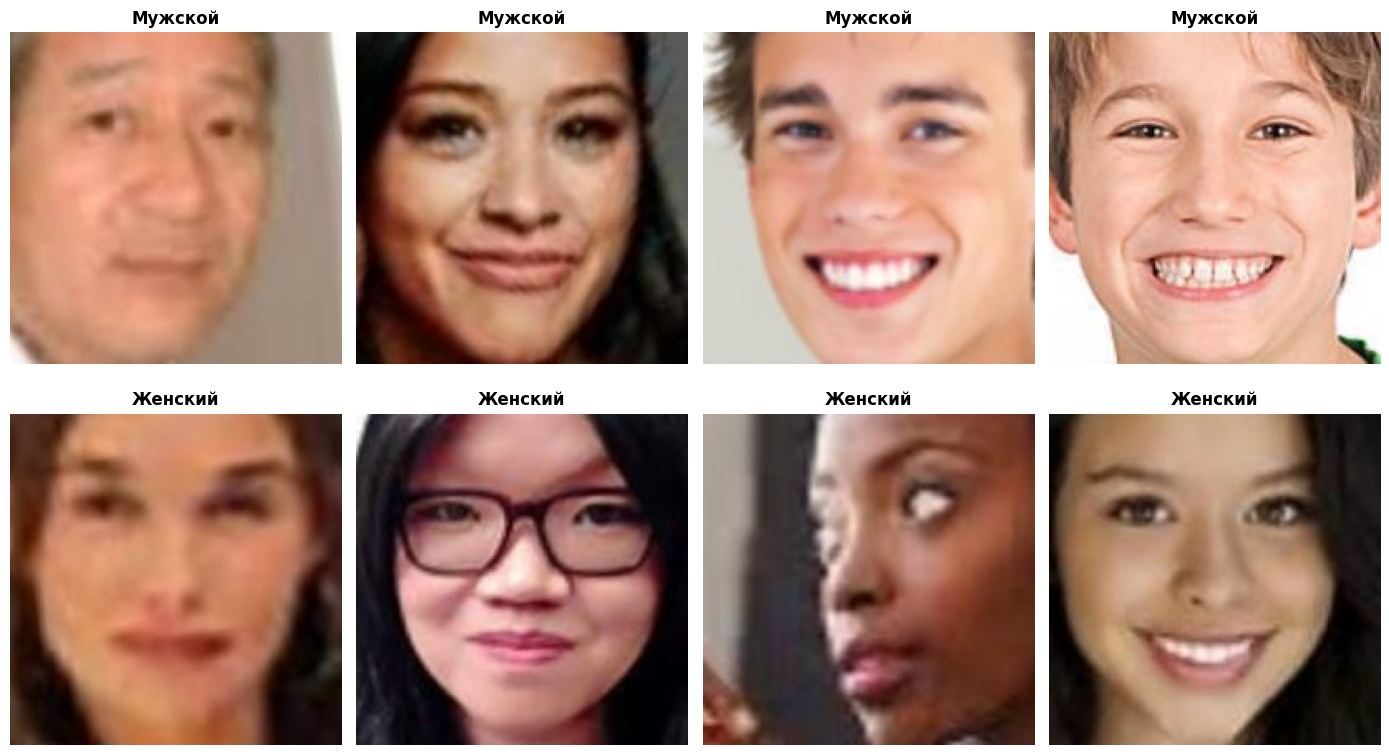

In [3]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.2 Примеры типичных изображений
# =========================================================================================
import random
from PIL import Image
import io

zip_path = '/content/UTKFace.zip'

# Параметры
samples_per_class = 4
random_seed = 42
output_image = '/content/typical_faces.jpg'

# Функция для определения пола
def get_gender(filename):
    base = os.path.basename(filename)
    name_no_ext = os.path.splitext(base)[0]
    parts = name_no_ext.split('_')
    if len(parts) >= 2:
        try:
            return int(parts[1])
        except:
            return None
    return None

# Сканируем архив
with zipfile.ZipFile(zip_path, 'r') as zf:
    img_files = [f for f in zf.namelist() if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

male_imgs = []
female_imgs = []

for f in img_files:
    g = get_gender(f)
    if g == 0:
        male_imgs.append(f)
    elif g == 1:
        female_imgs.append(f)

print(f'Найдено: мужских {len(male_imgs)}, женских {len(female_imgs)}')

# Случайная выборка
random.seed(random_seed)
male_sample = random.sample(male_imgs, min(samples_per_class, len(male_imgs)))
female_sample = random.sample(female_imgs, min(samples_per_class, len(female_imgs)))

# Формируем подписи
selected = []
for f in male_sample:
    selected.append(('Мужской', f))
for f in female_sample:
    selected.append(('Женский', f))

# Строим сетку 2 ряда x 4 колонки (верх – мужчины, низ – женщины)
fig, axes = plt.subplots(2, samples_per_class, figsize=(14, 8))
axes = axes.flatten()

with zipfile.ZipFile(zip_path, 'r') as zf:
    for idx, (label, fname) in enumerate(selected):
        data = zf.read(fname)
        img = Image.open(io.BytesIO(data))
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.axis('off')

# Скрываем лишние оси (если выборка меньше 8)
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(output_image, format='jpg', dpi=150, bbox_inches='tight')
print(f'Сетка сохранена в {output_image}')
plt.show()

Найдено: мужских 12391, женских 11317
Сетка сохранена в /content/typical_faces_512x512.jpg


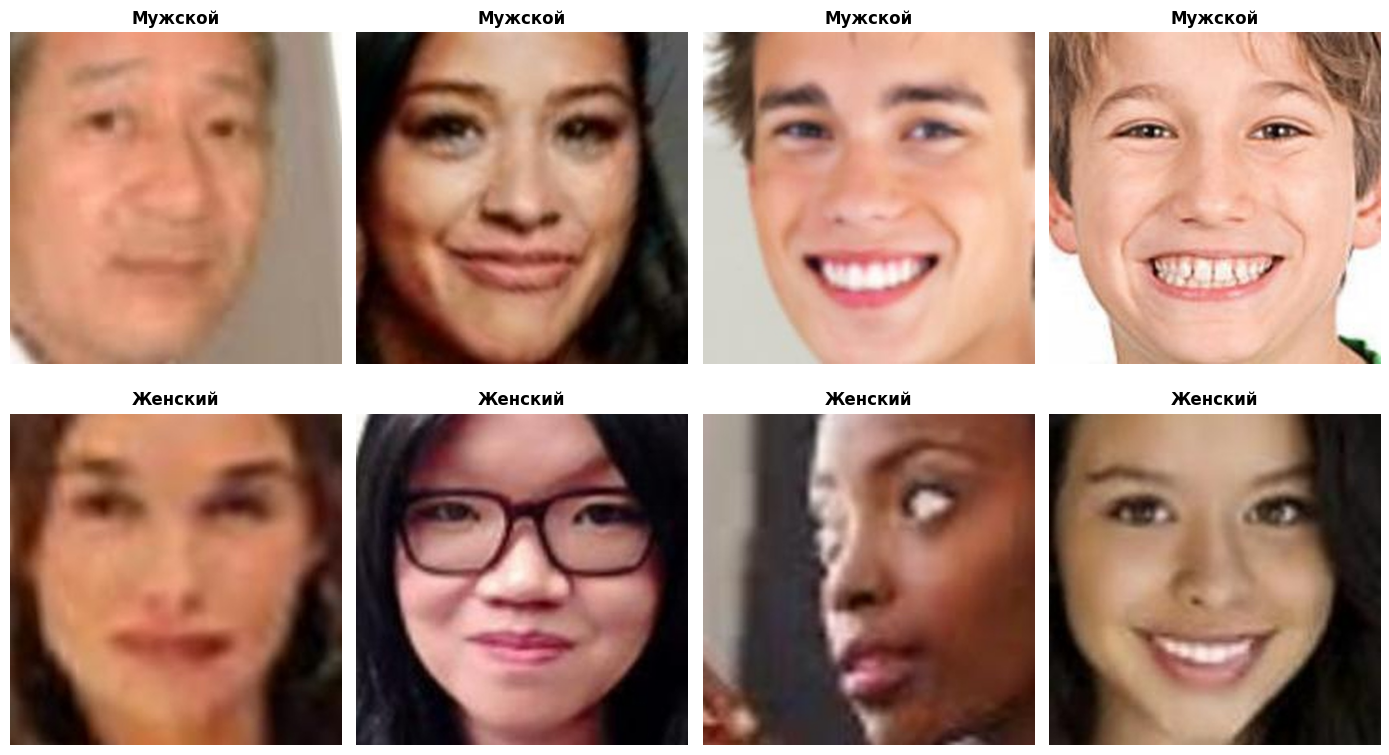

In [16]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.2 Примеры типичных изображений (после масштабирования)
# =========================================================================================
import random
from PIL import Image
import io

zip_path = '/content/UTKFace_512x512.zip'

# Параметры
samples_per_class = 4
random_seed = 42
output_image = '/content/typical_faces_512x512.jpg'

# Функция для определения пола
def get_gender(filename):
    base = os.path.basename(filename)
    name_no_ext = os.path.splitext(base)[0]
    parts = name_no_ext.split('_')
    if len(parts) >= 2:
        try:
            return int(parts[1])
        except:
            return None
    return None

# Сканируем архив
with zipfile.ZipFile(zip_path, 'r') as zf:
    img_files = [f for f in zf.namelist() if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

male_imgs = []
female_imgs = []

for f in img_files:
    g = get_gender(f)
    if g == 0:
        male_imgs.append(f)
    elif g == 1:
        female_imgs.append(f)

print(f'Найдено: мужских {len(male_imgs)}, женских {len(female_imgs)}')

# Случайная выборка
random.seed(random_seed)
male_sample = random.sample(male_imgs, min(samples_per_class, len(male_imgs)))
female_sample = random.sample(female_imgs, min(samples_per_class, len(female_imgs)))

# Формируем подписи
selected = []
for f in male_sample:
    selected.append(('Мужской', f))
for f in female_sample:
    selected.append(('Женский', f))

# Строим сетку 2 ряда x 4 колонки (верх – мужчины, низ – женщины)
fig, axes = plt.subplots(2, samples_per_class, figsize=(14, 8))
axes = axes.flatten()

with zipfile.ZipFile(zip_path, 'r') as zf:
    for idx, (label, fname) in enumerate(selected):
        data = zf.read(fname)
        img = Image.open(io.BytesIO(data))
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.axis('off')

# Скрываем лишние оси (если выборка меньше 8)
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(output_image, format='jpg', dpi=150, bbox_inches='tight')
print(f'Сетка сохранена в {output_image}')
plt.show()

In [5]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.3. Оценка качества изображений (до масштабирования)
# =========================================================================================
import numpy as np
from tqdm import tqdm

# Параметры
zip_path = '/content/UTKFace.zip'
output_hist = '/content/size_distribution.jpg'

# Сбор информации о размерах
widths, heights = [], []
corrupted = []   # битые файлы
zero_size = []   # файлы нулевого размера

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_img = [f for f in zf.namelist() if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f'Всего изображений в архиве: {len(all_img)}')

    for fname in tqdm(all_img, desc='Проверка качества'):
        info = zf.getinfo(fname)
        if info.file_size == 0:
            zero_size.append(fname)
            continue
        try:
            data = zf.read(fname)
            img = Image.open(io.BytesIO(data))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception:
            corrupted.append(fname)

# Вывод статистики
print(f'\nУспешно проверено:       {len(widths)}')
print(f'Битых файлов:            {len(corrupted)}')
print(f'Файлов нулевого размера: {len(zero_size)}')

if widths:
    widths_arr = np.array(widths)
    heights_arr = np.array(heights)
    unique_sizes = set(zip(widths, heights))
    print(f'Уникальных размеров: {len(unique_sizes)}')
    print(f'Минимальная ширина:  {widths_arr.min()}')
    print(f'Максимальная ширина: {widths_arr.max()}')
    print(f'Минимальная высота:  {heights_arr.min()}')
    print(f'Максимальная высота: {heights_arr.max()}')
    print(f'Средний размер:      {widths_arr.mean():.1f} x {heights_arr.mean():.1f}')

    # Если все размеры одинаковые, выведем текстом
    if len(unique_sizes) == 1:
        print('Все изображения имеют одинаковый размер. Гистограмма не требуется.')
    else:
        # Построим гистограммы для ширины и высоты
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.hist(widths_arr, bins=30, color='#B5D3E7', edgecolor='gray')
        ax1.set_title('Распределение ширины')
        ax1.set_xlabel('Ширина (px)')
        ax1.set_ylabel('Количество')

        ax2.hist(heights_arr, bins=30, color='#F4C2C2', edgecolor='gray')
        ax2.set_title('Распределение высоты')
        ax2.set_xlabel('Высота (px)')
        ax2.set_ylabel('Количество')

        plt.tight_layout()
        plt.savefig(output_hist, format='jpg', dpi=150, bbox_inches='tight')
        print(f'Гистограмма сохранена: {output_hist}')
        plt.show()
else:
    print('Не удалось прочитать ни одного изображения!')

Всего изображений в архиве: 23708


Проверка качества: 100%|██████████| 23708/23708 [00:02<00:00, 8687.15it/s]


Успешно проверено:       23708
Битых файлов:            0
Файлов нулевого размера: 0
Уникальных размеров: 1
Минимальная ширина:  200
Максимальная ширина: 200
Минимальная высота:  200
Максимальная высота: 200
Средний размер:      200.0 x 200.0
Все изображения имеют одинаковый размер. Гистограмма не требуется.


In [6]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.3. Масштабирование до размера 512x512 c помощью фильтра Ланцоша
# =========================================================================================
# Параметры
src_zip = '/content/UTKFace.zip'
dst_zip = '/content/UTKFace_512x512.zip'
target_size = (512, 512)

# Обработка
processed = 0
errors = 0

# Открываем исходник и создаём новый архив (режим 'w' — перезапись)
with zipfile.ZipFile(src_zip, 'r') as zin, \
     zipfile.ZipFile(dst_zip, 'w', zipfile.ZIP_DEFLATED) as zout:

    # Список всех файлов
    all_files = [f for f in zin.namelist() if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f'Найдено изображений: {len(all_files)}')

    for fname in tqdm(all_files, desc='Увеличение разрешения'):
        try:
            # Читаем исходное изображение
            data = zin.read(fname)
            img = Image.open(io.BytesIO(data))

            # Масштабируем с сохранением пропорций (но здесь квадрат 200×200 -> 512×512)
            # Для прямоугольных можно использовать Image.Resampling.LANCZOS
            img_resized = img.resize(target_size, Image.Resampling.LANCZOS)

            # Сохраняем в байтовый поток и добавляем в новый архив
            buf = io.BytesIO()
            img_resized.save(buf, format='JPEG', quality=95)
            zout.writestr(fname, buf.getvalue())
            processed += 1
        except Exception as e:
            print(f'Ошибка при обработке {fname}: {e}')
            errors += 1

print(f'\nГотово!')
print(f'Успешно обработано: {processed}')
print(f'Ошибок: {errors}')
print(f'Новый архив: {dst_zip}')

Найдено изображений: 23708


Увеличение разрешения: 100%|██████████| 23708/23708 [03:45<00:00, 105.04it/s]



Готово!
Успешно обработано: 23708
Ошибок: 0
Новый архив: /content/UTKFace_512x512.zip


In [7]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.3. Оценка качества изображений (после масштабирования)
# =========================================================================================
# Параметры
zip_path = '/content/UTKFace_512x512.zip'
output_hist = '/content/size_new_distribution.jpg'

# Сбор информации о размерах
widths, heights = [], []
corrupted = []   # битые файлы
zero_size = []   # файлы нулевого размера

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_img = [f for f in zf.namelist() if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f'Всего изображений в архиве: {len(all_img)}')

    for fname in tqdm(all_img, desc='Проверка качества'):
        info = zf.getinfo(fname)
        if info.file_size == 0:
            zero_size.append(fname)
            continue
        try:
            data = zf.read(fname)
            img = Image.open(io.BytesIO(data))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception:
            corrupted.append(fname)

# Вывод статистики
print(f'\nУспешно проверено:       {len(widths)}')
print(f'Битых файлов:            {len(corrupted)}')
print(f'Файлов нулевого размера: {len(zero_size)}')

if widths:
    widths_arr = np.array(widths)
    heights_arr = np.array(heights)
    unique_sizes = set(zip(widths, heights))
    print(f'Уникальных размеров: {len(unique_sizes)}')
    print(f'Минимальная ширина:  {widths_arr.min()}')
    print(f'Максимальная ширина: {widths_arr.max()}')
    print(f'Минимальная высота:  {heights_arr.min()}')
    print(f'Максимальная высота: {heights_arr.max()}')
    print(f'Средний размер:      {widths_arr.mean():.1f} x {heights_arr.mean():.1f}')

    # Если все размеры одинаковые, выведем текстом
    if len(unique_sizes) == 1:
        print('Все изображения имеют одинаковый размер. Гистограмма не требуется.')
    else:
        # Построим гистограммы для ширины и высоты
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.hist(widths_arr, bins=30, color='#B5D3E7', edgecolor='gray')
        ax1.set_title('Распределение ширины')
        ax1.set_xlabel('Ширина (px)')
        ax1.set_ylabel('Количество')

        ax2.hist(heights_arr, bins=30, color='#F4C2C2', edgecolor='gray')
        ax2.set_title('Распределение высоты')
        ax2.set_xlabel('Высота (px)')
        ax2.set_ylabel('Количество')

        plt.tight_layout()
        plt.savefig(output_hist, format='jpg', dpi=150, bbox_inches='tight')
        print(f'Гистограмма сохранена: {output_hist}')
        plt.show()
else:
    print('Не удалось прочитать ни одного изображения!')

Всего изображений в архиве: 23708


Проверка качества: 100%|██████████| 23708/23708 [00:06<00:00, 3571.21it/s]


Успешно проверено:       23708
Битых файлов:            0
Файлов нулевого размера: 0
Уникальных размеров: 1
Минимальная ширина:  512
Максимальная ширина: 512
Минимальная высота:  512
Максимальная высота: 512
Средний размер:      512.0 x 512.0
Все изображения имеют одинаковый размер. Гистограмма не требуется.


In [8]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.4.	Анализ аннотаций
# =========================================================================================
from collections import Counter

zip_path = '/content/UTKFace_512x512.zip'

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_names = zf.namelist()

# Только изображения
img_files = [f for f in all_names if f.lower().endswith(('.jpg','.jpeg','.png'))]

def parse_annotation(filename):
    """
    Возвращает (age, gender, race) или None, если имя не соответствует шаблону.
    """
    base = os.path.basename(filename)
    name_no_ext = os.path.splitext(base)[0]
    parts = name_no_ext.split('_')
    if len(parts) >= 3:
        try:
            age = int(parts[0])
            gender = int(parts[1])
            race = int(parts[2])
            return age, gender, race
        except ValueError:
            return None
    return None

# Анализ
annotations = []
invalid = []
for f in img_files:
    ann = parse_annotation(f)
    if ann is None:
        invalid.append(f)
    else:
        annotations.append(ann)

# 1. Примеры имён (для демонстрации формата)
print("=" * 60)
print("Примеры имён файлов (первые 10):")
print("=" * 60)
for i, f in enumerate(img_files[:10], 1):
    print(f"{i:2d}. {os.path.basename(f)}")

# 2. Статистика разбора
print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ АННОТАЦИЙ")
print("=" * 60)
print(f"Всего изображений:               {len(img_files)}")
print(f"Успешно распарсено:              {len(annotations)}")
print(f"Файлов с нераспознанным именем:  {len(invalid)}")

if invalid:
    print("\nПримеры файлов с некорректным именем:")
    for f in invalid[:10]:
        print(f"  - {os.path.basename(f)}")
else:
    print("Все имена соответствуют шаблону [age]_[gender]_[race]_[date&time].jpg")

# 3. Уникальные значения пола и их количество
if annotations:
    genders = [ann[1] for ann in annotations]
    gender_counts = Counter(genders)
    print("\nТаблица уникальных значений метки пола:")
    print("  Значение | Количество")
    print("  ---------+-----------")
    for label in sorted(gender_counts.keys()):
        print(f"  {label:8d} | {gender_counts[label]:6d}")

    # Проверка допустимых значений
    valid_genders = {0, 1}
    actual_genders = set(genders)
    if actual_genders == valid_genders:
        print("\nВсе метки пола корректны (только 0 и 1).")
    else:
        print(f"\nОбнаружены посторонние метки пола: {actual_genders - valid_genders}")
else:
    print("\nНе удалось извлечь ни одной аннотации. Проверьте целостность архива.")

Примеры имён файлов (первые 10):
 1. 100_0_0_20170112213500903.jpg.chip.jpg
 2. 100_0_0_20170112215240346.jpg.chip.jpg
 3. 100_1_0_20170110183726390.jpg.chip.jpg
 4. 100_1_0_20170112213001988.jpg.chip.jpg
 5. 100_1_0_20170112213303693.jpg.chip.jpg
 6. 100_1_0_20170112215032192.jpg.chip.jpg
 7. 100_1_0_20170117195420803.jpg.chip.jpg
 8. 100_1_0_20170119212053665.jpg.chip.jpg
 9. 100_1_2_20170105174847679.jpg.chip.jpg
10. 100_1_2_20170112213615815.jpg.chip.jpg

РЕЗУЛЬТАТЫ ПРОВЕРКИ АННОТАЦИЙ
Всего изображений:               23708
Успешно распарсено:              23705
Файлов с нераспознанным именем:  3

Примеры файлов с некорректным именем:
  - 39_1_20170116174525125.jpg.chip.jpg
  - 61_1_20170109142408075.jpg.chip.jpg
  - 61_1_20170109150557335.jpg.chip.jpg

Таблица уникальных значений метки пола:
  Значение | Количество
  ---------+-----------
         0 |  12391
         1 |  11314

Все метки пола корректны (только 0 и 1).


In [13]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.5.	Оценка качества разметки (ручная верификация)
# =========================================================================================
from IPython.display import display, clear_output
import ipywidgets as widgets
from collections import Counter

# НАСТРОЙКИ
zip_path = '/content/UTKFace_512x512.zip'
sample_size = 200
random_seed = 42

# ФУНКЦИЯ ИЗВЛЕЧЕНИЯ ПОЛА
def extract_gender(filename):
    base = os.path.basename(filename)
    name_no_ext = os.path.splitext(base)[0]
    parts = name_no_ext.split('_')
    if len(parts) >= 2:
        try:
            return int(parts[1])
        except:
            return None
    return None

# ПОДГОТОВКА ВЫБОРКИ
with zipfile.ZipFile(zip_path, 'r') as zf:
    all_images = [f for f in zf.namelist() if f.lower().endswith(('.jpg','.jpeg','.png'))]

labeled = [(f, extract_gender(f)) for f in all_images if extract_gender(f) is not None]
print(f'Всего размеченных изображений: {len(labeled)}')
random.seed(random_seed)
sample = random.sample(labeled, min(sample_size, len(labeled)))
print(f'Будет показано {len(sample)} изображений.\n')

# ПЕРЕМЕННЫЕ ДЛЯ ПРОВЕРКИ
results = []          # (filename, gender, verdict)
current_idx = 0
zf = zipfile.ZipFile(zip_path, 'r')  # будем держать открытым

# ИНТЕРФЕЙС
out_image = widgets.Output()
out_info = widgets.Output()
out_result = widgets.Output()

def show_next():
    """Показывает следующее изображение и обновляет информацию."""
    global current_idx
    with out_image:
        clear_output(wait=True)
        if current_idx < len(sample):
            fname, gender = sample[current_idx]
            data = zf.read(fname)
            img = Image.open(io.BytesIO(data))
            display(img)
            with out_info:
                clear_output(wait=True)
                print(f"📷 Изображение {current_idx+1} из {len(sample)}")
                print(f"🏷️ Метка: {gender} ({'мужской' if gender==0 else 'женский'})")
        else:
            # Завершение
            finish()

def finish():
    """Завершает проверку и выводит результаты."""
    with out_image:
        clear_output(wait=True)
        print("✅ Проверка завершена.")
    with out_info:
        clear_output(wait=True)
    # Вызываем анализ
    final_analysis()

def final_analysis():
    checked = [r for r in results if r[2] != 'skip']
    errors = sum(1 for r in checked if r[2] == False)
    skipped = sum(1 for r in results if r[2] == 'skip')
    total = len(results)
    with out_result:
        clear_output(wait=True)
        print("="*60)
        print("РЕЗУЛЬТАТЫ РУЧНОЙ ВЕРИФИКАЦИИ")
        print("="*60)
        print(f"Всего показано:    {total}")
        print(f"Проверено (y/n):   {len(checked)}")
        print(f"Пропущено:         {skipped}")
        print(f"Найдено ошибок:    {errors}")
        if checked:
            error_rate = 100 * errors / len(checked)
            print(f"Доля ошибок:       {error_rate:.2f}%")
        if errors > 0:
            print("\n❌ Ошибочные файлы:")
            for fname, gender, verdict in checked:
                if verdict == False:
                    print(f"  - {os.path.basename(fname)} (метка: {gender})")

# Обработчики кнопок
def on_yes(b):
    global current_idx
    fname, gender = sample[current_idx]
    results.append((fname, gender, True))
    current_idx += 1
    if current_idx >= len(sample):
        finish()
    else:
        show_next()

def on_no(b):
    global current_idx
    fname, gender = sample[current_idx]
    results.append((fname, gender, False))
    current_idx += 1
    if current_idx >= len(sample):
        finish()
    else:
        show_next()

def on_skip(b):
    global current_idx
    fname, gender = sample[current_idx]
    results.append((fname, gender, 'skip'))
    current_idx += 1
    if current_idx >= len(sample):
        finish()
    else:
        show_next()

def on_quit(b):
    global current_idx
    current_idx = len(sample)  # искусственно завершаем
    finish()

# Создаём кнопки
btn_yes = widgets.Button(description='✅ Верно (y)', button_style='success')
btn_no = widgets.Button(description='❌ Неверно (n)', button_style='danger')
btn_skip = widgets.Button(description='⏭ Пропустить', button_style='warning')
btn_quit = widgets.Button(description='⏹ Прервать', button_style='info')

btn_yes.on_click(on_yes)
btn_no.on_click(on_no)
btn_skip.on_click(on_skip)
btn_quit.on_click(on_quit)

buttons = widgets.HBox([btn_yes, btn_no, btn_skip, btn_quit])

# Отображаем интерфейс
display(out_image, out_info, buttons, out_result)

# Запускаем первое изображение
show_next()

Всего размеченных изображений: 23708
Будет показано 200 изображений.



Output()

Output()

Output()

In [14]:
# =========================================================================================
# 1.3	Описание результатов первичного анализа
# 1.3.4.	Структура каталогов и аннотации. Создание CSV файла.
# =========================================================================================
import csv

zip_path = '/content/UTKFace_512x512.zip'
random_seed = 42
train_ratio = 0.7
val_ratio = 0.15

def is_image(filename):
    """Проверяет, является ли запись файлом изображения, а не папкой."""
    # Папки в zip обычно заканчиваются на '/'
    if filename.endswith('/'):
        return False
    # Допустимые расширения
    return filename.lower().endswith(('.jpg', '.jpeg', '.png'))

def extract_label(filename):
    """Извлекает метку пола из ИМЕНИ файла, игнорируя путь."""
    basename = os.path.basename(filename)
    name_no_ext = os.path.splitext(basename)[0]
    parts = name_no_ext.split('_')
    if len(parts) >= 2:
        return parts[1]   # строка '0' или '1'
    return None

# Собираем изображения с метками
with zipfile.ZipFile(zip_path, 'r') as zf:
    all_names = zf.namelist()
    img_files = []
    for f in all_names:
        if is_image(f):
            label = extract_label(f)
            if label is not None:
                img_files.append((f, label))

print(f'Всего изображений с корректной меткой: {len(img_files)}')

# Перемешиваем и делим
random.seed(random_seed)
random.shuffle(img_files)
n = len(img_files)
n_train = int(n * train_ratio)
n_val   = int(n * val_ratio)

data_splits = []
for i, (fname, label) in enumerate(img_files):
    if i < n_train:
        split = 'train'
    elif i < n_train + n_val:
        split = 'val'
    else:
        split = 'test'
    data_splits.append((fname, label, split))

# Сохраняем CSV
csv_path = '/content/annotations_512x512.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['filepath', 'label', 'split'])
    writer.writerows(data_splits)

# Проверка первых строк
print(f'CSV сохранён: {csv_path}')
print(f'Train: {n_train}, Val: {n_val}, Test: {n - n_train - n_val}')
print('\nПервые 5 строк:')
with open(csv_path, 'r') as f:
    for _ in range(6):
        print(f.readline().strip())

Всего изображений с корректной меткой: 23708
CSV сохранён: /content/annotations_512x512.csv
Train: 16595, Val: 3556, Test: 3557

Первые 5 строк:
filepath,label,split
UTKFace/21_0_4_20161223214833090.jpg.chip.jpg,0,train
UTKFace/36_0_1_20170113142408744.jpg.chip.jpg,0,train
UTKFace/26_1_1_20170112230617333.jpg.chip.jpg,1,train
UTKFace/40_1_0_20170117154626844.jpg.chip.jpg,1,train
UTKFace/24_1_0_20170116214453175.jpg.chip.jpg,1,train
